<a href="https://colab.research.google.com/github/eduruiz2192-beep/TelecomX_parte2_Latam/blob/main/TelecomX_parte2_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Preparación de Datos y Encoding

In [2]:
import pandas as pd

# --- 1. FAST-TRACK ETL (Hacemos la limpieza de la Parte 1 en automático) ---
url_original = "https://raw.githubusercontent.com/eduruiz2192-beep/challenge-telecom-x-analisis-evasion-clientes/refs/heads/main/TelecomX_Data.json"
df_raw = pd.read_json(url_original)

# Aplanamos
df_customer = pd.json_normalize(df_raw['customer'])
df_phone = pd.json_normalize(df_raw['phone'])
df_internet = pd.json_normalize(df_raw['internet'])
df_account = pd.json_normalize(df_raw['account'])
df_limpio = pd.concat([df_raw[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

# Limpiamos nulos y creamos Churn_num
df_limpio['Charges.Total'] = pd.to_numeric(df_limpio['Charges.Total'], errors='coerce').fillna(0)
df_limpio = df_limpio[df_limpio['Churn'].isin(['Yes', 'No'])]
df_limpio['Churn_num'] = df_limpio['Churn'].map({'Yes': 1, 'No': 0})

print(f"1. Datos reconstruidos y limpios. Columnas base: {df_limpio.shape[1]}")

# --- 2. ELIMINACIÓN DE IRRELEVANTES (Parte 2) ---
df_modelo = df_limpio.drop(['customerID', 'Churn'], axis=1)

# --- 3. ENCODING ---
columnas_texto = df_modelo.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df_modelo, columns=columnas_texto, drop_first=True, dtype=int)
print(f"2. Encoding exitoso. Ahora tenemos {df_encoded.shape[1]} columnas matemáticas perfectas.")

# --- 4. VERIFICACIÓN DE PROPORCIÓN ---
print("\n--- 3. Proporción de Cancelación (Churn_num) ---")
print("Cantidad exacta:")
print(df_encoded['Churn_num'].value_counts())
print("\nPorcentaje (%):")
print((df_encoded['Churn_num'].value_counts(normalize=True) * 100).round(2))

1. Datos reconstruidos y limpios. Columnas base: 22
2. Encoding exitoso. Ahora tenemos 31 columnas matemáticas perfectas.

--- 3. Proporción de Cancelación (Churn_num) ---
Cantidad exacta:
Churn_num
0    5174
1    1869
Name: count, dtype: int64

Porcentaje (%):
Churn_num
0    73.46
1    26.54
Name: proportion, dtype: float64


## 2. Balanceo de Clases (SMOTE) y Normalización

In [3]:
# Importamos las herramientas matemáticas
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# --- 1. SEPARAMOS LA TABLA ---
# 'X' será toda la información de los clientes, 'y' será la respuesta (si canceló o no)
X = df_encoded.drop('Churn_num', axis=1)
y = df_encoded['Churn_num']

# --- 2. BALANCEO DE CLASES (Tarjeta 5 del Trello) ---
# Usamos SMOTE para clonar clientes que cancelaron y equilibrar la balanza a 50/50
smote = SMOTE(random_state=42)
X_balanceado, y_balanceado = smote.fit_resample(X, y)

print("--- ANTES DEL BALANCEO ---")
print(y.value_counts())
print("\n--- DESPUÉS DEL BALANCEO (SMOTE) ---")
print(y_balanceado.value_counts())

# --- 3. NORMALIZACIÓN / ESTANDARIZACIÓN (Tarjeta 6 del Trello) ---
# Escalar los números grandes para que no opaquen a los pequeños
scaler = StandardScaler()
columnas_numericas = ['tenure', 'Charges.Monthly', 'Charges.Total']

# Aplicamos la escala solo a las columnas de números grandes
X_balanceado_scaled = X_balanceado.copy()
X_balanceado_scaled[columnas_numericas] = scaler.fit_transform(X_balanceado[columnas_numericas])

print("\n¡Datos balanceados y estandarizados correctamente! Listos para los modelos.")

--- ANTES DEL BALANCEO ---
Churn_num
0    5174
1    1869
Name: count, dtype: int64

--- DESPUÉS DEL BALANCEO (SMOTE) ---
Churn_num
0    5174
1    5174
Name: count, dtype: int64

¡Datos balanceados y estandarizados correctamente! Listos para los modelos.


## 3. Análisis de Correlación y Análisis Dirigido

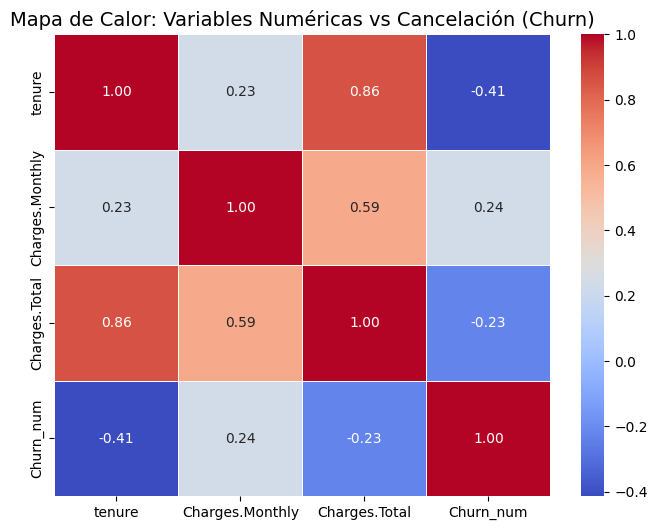

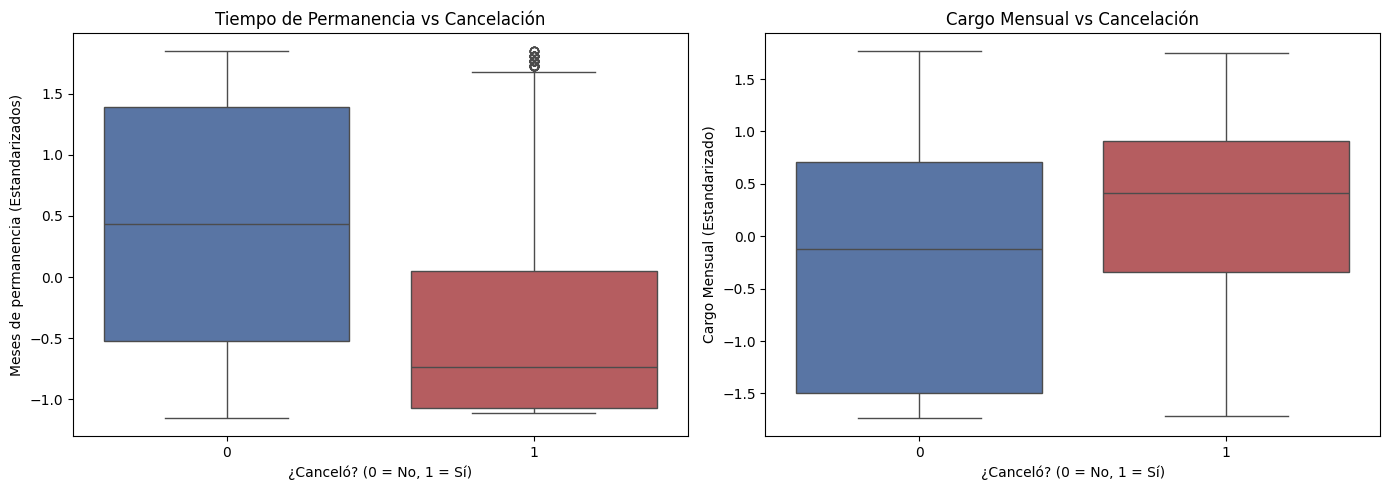

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

df_analisis = X_balanceado_scaled.copy()
df_analisis['Churn_num'] = y_balanceado

# --- 1. MATRIZ DE CORRELACIÓN ---
columnas_corr = ['tenure', 'Charges.Monthly', 'Charges.Total', 'Churn_num']
matriz_corr = df_analisis[columnas_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor: Variables Numéricas vs Cancelación (Churn)', fontsize=14)
plt.show()

# --- 2. ANÁLISIS DIRIGIDO (Sin advertencias molestas) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_analisis, x='Churn_num', y='tenure', hue='Churn_num', palette=['#4C72B0', '#C44E52'], legend=False, ax=axes[0])
axes[0].set_title('Tiempo de Permanencia vs Cancelación')
axes[0].set_xlabel('¿Canceló? (0 = No, 1 = Sí)')
axes[0].set_ylabel('Meses de permanencia (Estandarizados)')

sns.boxplot(data=df_analisis, x='Churn_num', y='Charges.Monthly', hue='Churn_num', palette=['#4C72B0', '#C44E52'], legend=False, ax=axes[1])
axes[1].set_title('Cargo Mensual vs Cancelación')
axes[1].set_xlabel('¿Canceló? (0 = No, 1 = Sí)')
axes[1].set_ylabel('Cargo Mensual (Estandarizado)')

plt.tight_layout()
plt.show()

## 4. Separación de Datos y Entrenamiento de Modelos

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- 1. SEPARACIÓN DE DATOS (Train/Test Split) ---
# Separamos 70% para entrenar y 30% para probar
X_train, X_test, y_train, y_test = train_test_split(X_balanceado_scaled, y_balanceado, test_size=0.3, random_state=42)

print(f"Datos de Entrenamiento: {X_train.shape[0]} clientes.")
print(f"Datos de Prueba (Examen): {X_test.shape[0]} clientes.\n")

# --- 2. CREACIÓN Y ENTRENAMIENTO DE MODELOS ---

# Modelo 1: Regresión Logística
modelo_logistico = LogisticRegression(max_iter=1000)
modelo_logistico.fit(X_train, y_train) # Aquí la máquina está estudiando
print("✅ Modelo 1 (Regresión Logística) entrenado.")

# Modelo 2: Random Forest (Bosque Aleatorio)
modelo_bosque = RandomForestClassifier(random_state=42)
modelo_bosque.fit(X_train, y_train) # Aquí la máquina está estudiando
print("✅ Modelo 2 (Random Forest) entrenado.")

Datos de Entrenamiento: 7243 clientes.
Datos de Prueba (Examen): 3105 clientes.

✅ Modelo 1 (Regresión Logística) entrenado.
✅ Modelo 2 (Random Forest) entrenado.


## 5. Evaluación de los Modelos (El Examen Final)

🏆 --- RESULTADOS: REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1588
           1       0.81      0.84      0.83      1517

    accuracy                           0.83      3105
   macro avg       0.83      0.83      0.83      3105
weighted avg       0.83      0.83      0.83      3105


🌲 --- RESULTADOS: RANDOM FOREST (BOSQUE ALEATORIO) ---
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1588
           1       0.83      0.83      0.83      1517

    accuracy                           0.84      3105
   macro avg       0.84      0.84      0.84      3105
weighted avg       0.84      0.84      0.84      3105



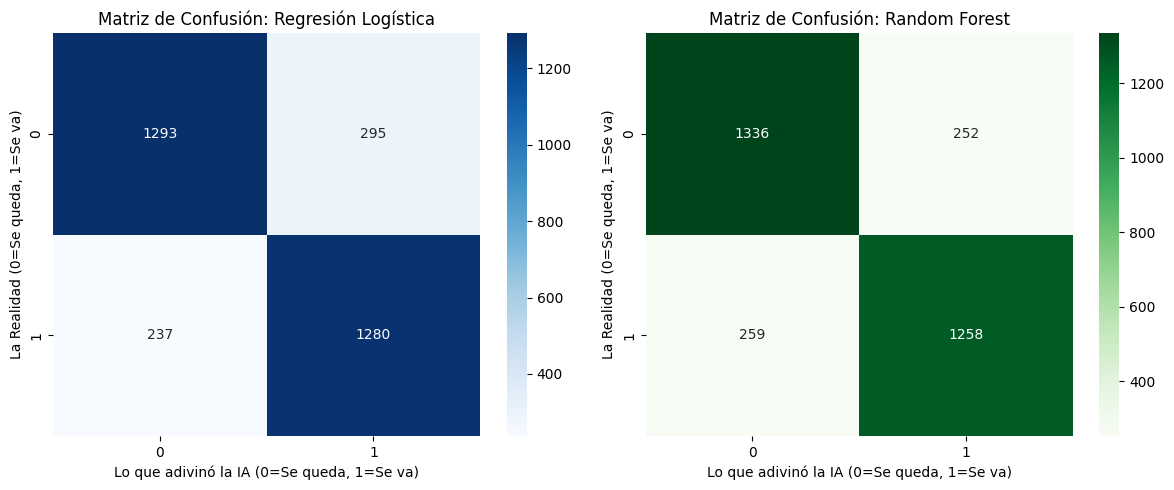

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. LAS MÁQUINAS RINDEN EL EXAMEN ---
# Les damos los datos de prueba (los 3105 clientes que no han visto) para que adivinen si cancelan o no
predicciones_logistico = modelo_logistico.predict(X_test)
predicciones_bosque = modelo_bosque.predict(X_test)

# --- 2. BOLETAS DE CALIFICACIONES (Métricas) ---
print("🏆 --- RESULTADOS: REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, predicciones_logistico))

print("\n🌲 --- RESULTADOS: RANDOM FOREST (BOSQUE ALEATORIO) ---")
print(classification_report(y_test, predicciones_bosque))

# --- 3. MATRIZ DE CONFUSIÓN (¡Los gráficos!) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico para Regresión Logística
sns.heatmap(confusion_matrix(y_test, predicciones_logistico), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de Confusión: Regresión Logística')
axes[0].set_xlabel('Lo que adivinó la IA (0=Se queda, 1=Se va)')
axes[0].set_ylabel('La Realidad (0=Se queda, 1=Se va)')

# Gráfico para Random Forest
sns.heatmap(confusion_matrix(y_test, predicciones_bosque), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Matriz de Confusión: Random Forest')
axes[1].set_xlabel('Lo que adivinó la IA (0=Se queda, 1=Se va)')
axes[1].set_ylabel('La Realidad (0=Se queda, 1=Se va)')

plt.tight_layout()
plt.show()

## 6. Importancia de las Variables (¿Qué influye más?)

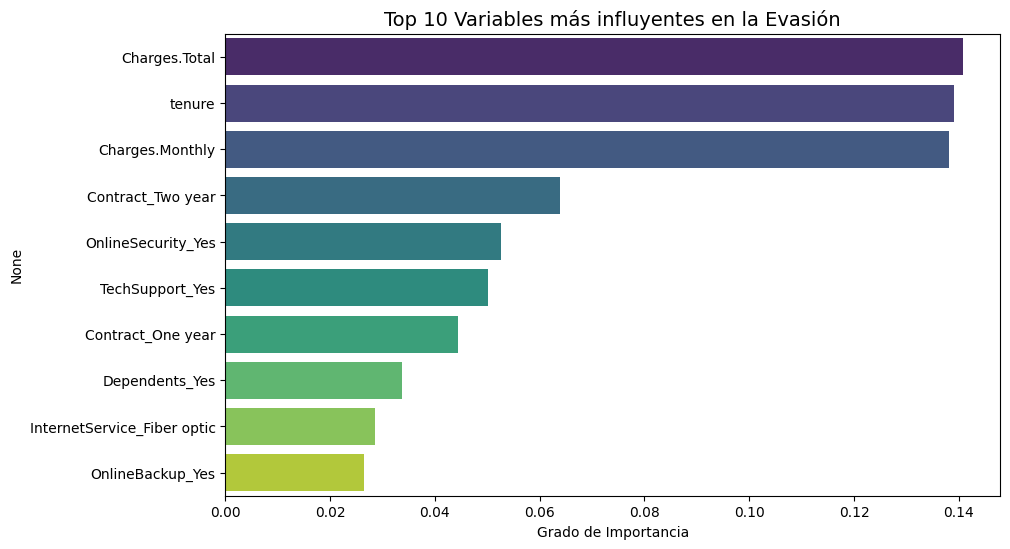

In [9]:
import numpy as np

# Extraemos la importancia de las variables del modelo Random Forest
importancias = modelo_bosque.feature_importances_
nombres_variables = X.columns

# Lo ordenamos de mayor a menor para que se vea bien
indices = np.argsort(importancias)[::-1]

# Graficamos el Top 10 de variables que más influyen
plt.figure(figsize=(10, 6))
plt.title("Top 10 Variables más influyentes en la Evasión", fontsize=14)
sns.barplot(x=importancias[indices[:10]], y=nombres_variables[indices[:10]], palette='viridis', hue=nombres_variables[indices[:10]], legend=False)
plt.xlabel("Grado de Importancia")
plt.show()

## 7. Conclusiones y Estrategia de Retención

1. Desempeño del Modelo:

Se desarrollaron dos modelos de Machine Learning, siendo el Random Forest el más efectivo con una precisión del 84%. El modelo es capaz de identificar correctamente a los clientes en riesgo de fuga, permitiendo actuar antes de que cancelen.

2. Factores Críticos de Evasión (Insights):

Tenure (Antigüedad): Es el factor número uno. Los clientes nuevos tienen una probabilidad drásticamente mayor de abandonar.

Cargos Mensuales y Totales: El costo del servicio sigue siendo un motor de fuga; los clientes con facturas más altas son más propensos a buscar competencia.

Contrato: Los clientes con contratos mes a mes son los más volátiles.

3. Recomendaciones para Telecom X:

Alertas Tempranas: Implementar el modelo Random Forest en la base de datos real para generar una "Alerta Roja" cuando un cliente nuevo (tenure bajo) con contrato mensual empiece a mostrar comportamientos de queja o altos cargos.

Plan de Bienvenida: Ofrecer descuentos o beneficios exclusivos durante los primeros 6 meses para "anclar" al cliente y superar la barrera crítica de antigüedad.

Migración de Contrato: Crear una campaña dirigida a clientes de "mes a mes" para ofrecerles un upgrade a contrato anual con un beneficio tangible (ej. más gigas o streaming gratis).